In [72]:
# %pip install -qU "langchain-google-community[gmail]"
# %pip install -qU langchain-community arxiv
#%pip install -qU langchain-classic langchain-community arxiv #옛 방식 arxiv 패키지

In [73]:
from dotenv import load_dotenv
load_dotenv()

True

In [74]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o")
small_llm = ChatOpenAI(model="gpt-4o-mini")

In [75]:
from langchain_core.tools import tool

@tool
def add(a: int, b: int) -> int:
    """숫자 a와 b를 더합니다."""
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """숫자 a와 b를 곱합니다."""
    return a * b

In [76]:
from langchain_community.tools import DuckDuckGoSearchRun
search_tool = DuckDuckGoSearchRun()


In [77]:
from langchain_google_community import GmailToolkit
from langchain_google_community.gmail.utils import (
    build_resource_service,
    get_gmail_credentials,
)

# Can review scopes here https://developers.google.com/gmail/api/auth/scopes
# For instance, readonly scope is 'https://www.googleapis.com/auth/gmail.readonly'
credentials = get_gmail_credentials(
    token_file="./google/gmail_token.json",
    scopes=["https://mail.google.com/"],
    client_sercret_file="./google/gmail_credentials.json",
)
api_resource = build_resource_service(credentials=credentials)
gmail_toolkit = GmailToolkit(api_resource=api_resource)
gmail_tool_list = gmail_toolkit.get_tools()

C:\Users\JJH\AppData\Local\Temp\ipykernel_11316\3256258543.py:9: DeprecationWarning: get_gmail_credentials is deprecated and will be removed in a future version.Use get_google_credentials instead.
  credentials = get_gmail_credentials(
C:\Users\JJH\AppData\Local\Temp\ipykernel_11316\3256258543.py:14: DeprecationWarning: build_resource_service is deprecated and will be removed in a future version.Use build_gmail_service instead.
  api_resource = build_resource_service(credentials=credentials)


In [78]:
gmail_tool_list

[GmailCreateDraft(api_resource=<googleapiclient.discovery.Resource object at 0x000001D03F3844A0>),
 GmailSendMessage(api_resource=<googleapiclient.discovery.Resource object at 0x000001D03F3844A0>),
 GmailSearch(api_resource=<googleapiclient.discovery.Resource object at 0x000001D03F3844A0>),
 GmailGetMessage(api_resource=<googleapiclient.discovery.Resource object at 0x000001D03F3844A0>),
 GmailGetThread(api_resource=<googleapiclient.discovery.Resource object at 0x000001D03F3844A0>)]

In [79]:
from langchain_classic.agents import load_tools

loaded_tools_list = load_tools(
    ["arxiv"],
)

In [80]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_core.tools.retriever import create_retriever_tool

embedding_function = OpenAIEmbeddings(model='text-embedding-3-large')

vector_store = Chroma(
    embedding_function=embedding_function,
    collection_name = 'real_estate_tax',
    persist_directory='./real_estate_tax_collection'
)
retriever = vector_store.as_retriever(search_kwargs={'k': 3})
retriever_tool = create_retriever_tool(
    retriever=retriever,
    name='real_estate_tax_retriever',
    description='Contains information about real estate tax up to May 2026',
    )

In [81]:
from langgraph.prebuilt import ToolNode

tool_list = [add, multiply,search_tool, retriever_tool] + gmail_tool_list + loaded_tools_list
llm_with_tools = small_llm.bind_tools(tool_list)
tool_node = ToolNode(tool_list)

In [82]:
from langgraph.graph import MessagesState, StateGraph

class AgentState(MessagesState):
    summary: str

graph_builder = StateGraph(AgentState)

In [83]:
from langchain_core.messages import SystemMessage

def agent(state: AgentState) -> AgentState:

    messages = state['messages']
    summary = state['summary']
    
    if summary != '':
        messages = [SystemMessage(content=f'Here is the summary of the earlier conversation: {summary}')] + messages
    
    response = llm_with_tools.invoke(messages)
    
    return {'messages': [response]}

In [84]:
from typing import Literal
from langgraph.types import interrupt, Command

def human_review(state: AgentState) -> Command[Literal['tools', 'agent']]:
    messages = state['messages']
    last_message = messages[-1]
    tool_call = last_message.tool_calls[-1]
    human_review = interrupt({
        'question': '이렇게 진행하면 될까요?',
        'tool_call': tool_call
    })
    review_action = human_review['action']
    review_data = human_review.get('data', None)
    
    if review_action == 'continue':
        return Command(goto='tools')
    
    if review_action == 'update_args':
        updated_ai_message = {
            'id': last_message.id,
            'role': 'ai',
            'content': last_message.content,
            'tool_calls': [{
                'id': tool_call['id'],
                'name': tool_call['name'],
                'args': review_data
            }],
        }
        return Command(goto='tools', update={'messages': [updated_ai_message]})
    
    if review_action == 'update_tool': 
        updated_tool_message = {
            'tool_call_id': tool_call['id'],
            'name': tool_call['name'],
            'role': 'tool',
            'content': review_data
        }
        return Command(goto='agent', update={'messages': [updated_tool_message]})


In [85]:
def summarize_messages(state: AgentState) -> AgentState:
    messages = state['messages']
    summary = state['summary']
    
    summary_prompt = f'summarize this chat history below: \n\nchat_history:{messages}'
    
    if summary != '':
        summary_prompt = f'''summarize this chat history below while looking at the summary of earlier conversations
chat_history:{messages}
summary:{summary}'''

    summary = small_llm.invoke(summary_prompt)
    return {'summary': summary.content}

In [86]:
from langchain_core.messages import RemoveMessage

def delete_messages(state: AgentState) -> AgentState:
    
    messages = state['messages']
    delete_messages = [RemoveMessage(id=message.id) for message in messages[:-3]]
    return {'messages': delete_messages}

In [87]:
from typing import Literal

def should_continue(state: AgentState) -> Literal['tools', 'summarize_messages']:

    messages = state['messages']
    last_ai_message = messages[-1]
    
    if last_ai_message.tool_calls:
        return 'human_review'
    
    return 'summarize_messages'

In [88]:
graph_builder.add_node('agent', agent)
graph_builder.add_node('tools', tool_node)
graph_builder.add_node(human_review)
graph_builder.add_node(delete_messages)
graph_builder.add_node(summarize_messages)

In [89]:
from langgraph.graph import START, END
from langgraph.prebuilt import tools_condition

graph_builder.add_edge(START, 'agent')
graph_builder.add_conditional_edges(
    'agent',
    should_continue,
    ['human_review', 'summarize_messages']
)
graph_builder.add_edge('tools', 'agent')
graph_builder.add_edge('summarize_messages', 'delete_messages')
graph_builder.add_edge('delete_messages', END)


In [90]:
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()

graph= graph_builder.compile(
    checkpointer = checkpointer
)

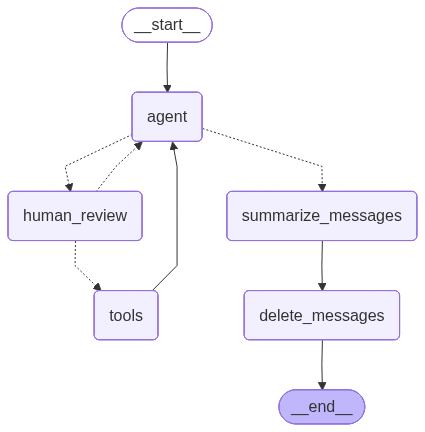

In [91]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [92]:
from langchain_core.messages import HumanMessage

config = {
    'configurable': {
        'thread_id': 'summarize_paper'
    }
}

query = 'LLM Survey 논문의 내용을 검색해서 요약해주세요'
for chunk in graph.stream({'messages': [HumanMessage(query)], 'summary': ''}, config=config, stream_mode='values'):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

LLM Survey 논문의 내용을 검색해서 요약해주세요
================================== Ai Message ==================================
Tool Calls:
  arxiv (call_5HP0SQSiwunTEM0MNu1yNF06)
 Call ID: call_5HP0SQSiwunTEM0MNu1yNF06
  Args:
    query: LLM Survey
================================== Ai Message ==================================
Tool Calls:
  arxiv (call_5HP0SQSiwunTEM0MNu1yNF06)
 Call ID: call_5HP0SQSiwunTEM0MNu1yNF06
  Args:
    query: LLM Survey


In [93]:
for chunk in graph.stream(
    Command(resume={
        "action": "update_args",
        "data": {"query": 'Large Language Model: A Survey'}
        },
    ),
    config=config,
    stream_mode="updates",
):
    print(chunk)

{'human_review': {'messages': [{'id': 'lc_run--019df26a-6398-7092-a802-1d54946e5f81-0', 'role': 'ai', 'content': '', 'tool_calls': [{'id': 'call_5HP0SQSiwunTEM0MNu1yNF06', 'name': 'arxiv', 'args': {'query': 'Large Language Model: A Survey'}}]}]}}
{'tools': {'messages': [ToolMessage(content="Published: 2015-08-17\nTitle: Observation of the rare $B^0_s\\toμ^+μ^-$ decay from the combined analysis of CMS and LHCb data\nAuthors: The CMS, LHCb Collaborations, :, V. Khachatryan, A. M. Sirunyan, A. Tumasyan, W. Adam, T. Bergauer, M. Dragicevic, J. Erö, M. Friedl, R. Frühwirth, V. M. Ghete, C. Hartl, N. Hörmann, J. Hrubec, M. Jeitler, W. Kiesenhofer, V. Knünz, M. Krammer, I. Krätschmer, D. Liko, I. Mikulec, D. Rabady, B. Rahbaran, H. Rohringer, R. Schöfbeck, J. Strauss, W. Treberer-Treberspurg, W. Waltenberger, C. -E. Wulz, V. Mossolov, N. Shumeiko, J. Suarez Gonzalez, S. Alderweireldt, S. Bansal, T. Cornelis, E. A. De Wolf, X. Janssen, A. Knutsson, J. Lauwers, S. Luyckx, S. Ochesanu, R. Rougny

In [96]:
for chunk in graph.stream(
    Command(resume={"action": "update_tool", "data": "arxiv말고 web에서 검색해주세요"}),
    config,
    stream_mode="updates",
):
    print(chunk)

{'human_review': {'messages': [{'tool_call_id': 'call_49pnDfSRJQGMweJK22tBDSBY', 'name': 'duckduckgo_search', 'role': 'tool', 'content': 'arxiv말고 web에서 검색해주세요'}]}}
{'agent': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 2609, 'total_tokens': 2633, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 2560}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_11121efef4', 'id': 'chatcmpl-DbkQIwpIuuIL8BH2wsj5l6sDER67e', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019df270-9315-7881-bf5d-bc5745ce2e76-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'Large Language Model Survey 2023 overview'}, 'id': 'call_QuzowX8DJUehxgZW60Yk1OrH', 'type': '

In [97]:
for chunk in graph.stream(
    Command(resume={"action": "continue"}),
    config,
    stream_mode="updates",
):
    print(f'chunk == {chunk}')

chunk == {'human_review': None}
chunk == {'tools': {'messages': [ToolMessage(content='September 9, 2025 - This survey provides an in-depth review of large language models (LLMs), highlighting the significant paradigm shift they represent in artificial intelligence. Our purpose is to consolidate state-of-the-art advances in LLM design, training, ... March 18, 2026 - [Submitted on 31 Mar 2023 (v1), last revised 18 Mar 2026 (this version, v19)] Authors:Wayne Xin Zhao, Kun Zhou, Junyi Li, Tianyi Tang, Xiaolei Wang, Yupeng Hou, Yingqian Min, Beichen Zhang, Junjie Zhang, Zican Dong, Yifan Du, Chen Yang, Yushuo Chen, Zhipeng Chen, Jinhao Jiang, Ruiyang Ren, Yifan Li, Xinyu Tang, Zikang Liu, Peiyu Liu, Jian-Yun Nie, Ji-Rong Wen · View a PDF of the paper titled A Survey of Large Language Models, by Wayne Xin Zhao and 20 other authors View PDF · August 11, 2025 - This survey offers an in-depth review of Large Language Models (LLMs), highlighting the significant paradigm shift they represent in a

In [98]:
graph.get_state(config).values['messages']

[AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 2609, 'total_tokens': 2633, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 2560}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_11121efef4', 'id': 'chatcmpl-DbkQIwpIuuIL8BH2wsj5l6sDER67e', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019df270-9315-7881-bf5d-bc5745ce2e76-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'Large Language Model Survey 2023 overview'}, 'id': 'call_QuzowX8DJUehxgZW60Yk1OrH', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 2609, 'output_tokens': 24, 'total_tokens': 2633, 'input_token_details': {'audio': 0, 'cache_read': 2560}, 'output_toke